In [1]:
import torch
import numpy as np
from datasets import load_dataset
from evaluate import load as load_metric

print(f"✅ GPU disponible: {torch.cuda.is_available()}")
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

✅ GPU disponible: True
✅ GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
from transformers import T5Tokenizer

MODEL_NAME = "google/flan-t5-base"
print("⏳ Descargando tokenizer...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer listo")

⏳ Descargando tokenizer...
✅ Tokenizer listo


In [3]:
from transformers import T5ForConditionalGeneration

print("⏳ Descargando modelo FLAN-T5 base...")
print("(Primera vez tarda 2-3 minutos, después es instantáneo)")
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to("cuda")
print("✅ Modelo cargado en GPU")

⏳ Descargando modelo FLAN-T5 base...
(Primera vez tarda 2-3 minutos, después es instantáneo)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Modelo cargado en GPU


In [4]:
def predict_sentiment(text, max_input_length=512):
    prompt = f"Classify the sentiment of this movie review as 'positive' or 'negative':\n\n{text}"
    
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=max_input_length,
        truncation=True
    ).to("cuda")
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=10
    )
    
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()
    
    if "positive" in prediction:
        return 1
    elif "negative" in prediction:
        return 0
    else:
        return -1

print("✅ Función de predicción lista")

✅ Función de predicción lista


In [5]:
ejemplos = [
    "This movie was absolutely amazing! The acting was superb and the story kept me hooked.",
    "Terrible film. Boring, slow, and a complete waste of time. I want my money back.",
    "One of the best movies I have ever seen. A masterpiece of cinema.",
    "The worst movie of the year. Awful script and horrible acting."
]

print("🎬 PRUEBAS MANUALES\n")
for texto in ejemplos:
    resultado = predict_sentiment(texto)
    emoji = "✅ Positivo" if resultado == 1 else "❌ Negativo" if resultado == 0 else "❓ Indefinido"
    print(f"Reseña: {texto[:80]}...")
    print(f"Resultado: {emoji}\n")

🎬 PRUEBAS MANUALES

Reseña: This movie was absolutely amazing! The acting was superb and the story kept me h...
Resultado: ✅ Positivo

Reseña: Terrible film. Boring, slow, and a complete waste of time. I want my money back....
Resultado: ❌ Negativo

Reseña: One of the best movies I have ever seen. A masterpiece of cinema....
Resultado: ✅ Positivo

Reseña: The worst movie of the year. Awful script and horrible acting....
Resultado: ❌ Negativo



In [10]:
dataset = load_dataset("stanfordnlp/imdb")

# Tomamos 100 positivas y 100 negativas balanceadas
positivas = dataset["test"].filter(lambda x: x["label"] == 1).select(range(100))
negativas = dataset["test"].filter(lambda x: x["label"] == 0).select(range(100))

from datasets import concatenate_datasets
muestra = concatenate_datasets([positivas, negativas])

print("⏳ Evaluando baseline con 200 ejemplos balanceados...")
print(f"Positivas: 100 | Negativas: 100\n")

y_true = []
y_pred = []

for i, ejemplo in enumerate(muestra):
    pred = predict_sentiment(ejemplo["text"])
    y_true.append(ejemplo["label"])
    y_pred.append(pred if pred != -1 else 0)
    
    if (i + 1) % 50 == 0:
        print(f"  Progreso: {i+1}/200")

print("\n✅ Evaluación completa")

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

⏳ Evaluando baseline con 200 ejemplos balanceados...
Positivas: 100 | Negativas: 100

  Progreso: 50/200
  Progreso: 100/200
  Progreso: 150/200
  Progreso: 200/200

✅ Evaluación completa


In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("📊 MÉTRICAS BASELINE (sin fine-tune)")
print(f"{'='*40}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")
print(f"{'='*40}")
print("\nReporte detallado:")
print(classification_report(y_true, y_pred, target_names=["Negativo", "Positivo"]))

import json
baseline_metrics = {"accuracy": accuracy, "f1": f1}
with open("baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f)
print("✅ Métricas guardadas en baseline_metrics.json")

📊 MÉTRICAS BASELINE (sin fine-tune)
Accuracy: 0.9350 (93.50%)
F1 Score: 0.9372

Reporte detallado:
              precision    recall  f1-score   support

    Negativo       0.97      0.90      0.93       100
    Positivo       0.91      0.97      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200

✅ Métricas guardadas en baseline_metrics.json


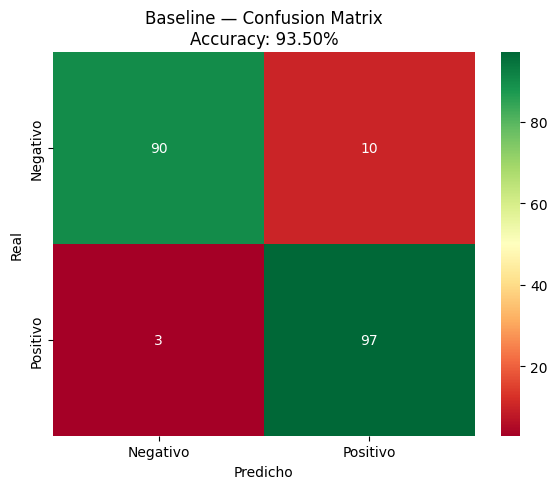

✅ Gráfica guardada


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"])
plt.title(f"Baseline — Confusion Matrix\nAccuracy: {accuracy*100:.2f}%")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png")
plt.show()
print("✅ Gráfica guardada")